This notebook documents the implementation and results of the Convolutional Photonic Reservoir Computing (CPRC) model.

This project explores a novel hybrid classical-quantum machine learning architecture designed for high-performance time-series analysis and forecasting. The model leverages the inherent physical properties of a simulated photonic quantum processor (the reservoir) to perform high-dimensional, non-linear feature mapping—acting as an advanced quantum kernel.

The core objective is to achieve demonstrable quantum advantage over conventional classical algorithms (such as LSTMs), combining the strengths of classical data handling with the superior expressivity and parallelism of quantum computing.

In [1]:
import perceval as pcvl
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import pandas as pd

class ConvolutionalPhotonicReservoir:
    def __init__(self, kernel_size, depth=None):
        # Removed 'features_per_kernel' argument as it is auto-detected
        self.n_modes = kernel_size
        
        self.regression = Ridge(alpha=1e-5) 
        self.input_scaler = MinMaxScaler(feature_range=(0, 2*np.pi))
        
        self.depth = depth if depth is not None else kernel_size
        
        # Reservoir parameters (Fixed Random)
        rng = np.random.default_rng(seed=42)
        self.reservoir_thetas = []
        for d in range(self.depth):
            row_thetas = []
            for i in range(d % 2, self.n_modes - 1, 2):
                row_thetas.append(rng.uniform(0, 2 * np.pi))
            self.reservoir_thetas.append(row_thetas)

        # Input State
        if self.n_modes <= 8:
             self.input_state = pcvl.BasicState([1] * self.n_modes)
        else:
             state_list = [1 if i % 2 == 0 else 0 for i in range(self.n_modes)]
             self.input_state = pcvl.BasicState(state_list)
             
        # Initialize states and set n_outputs automatically
        self._init_states()

    def _init_states(self):
        """ Discover all possible quantum states to define feature space. """
        c = pcvl.Circuit(self.n_modes)
        for i in range(0, self.n_modes - 1, 2): c.add(i, pcvl.BS()) 
        for i in range(self.n_modes): c.add(i, pcvl.PS(0.1))        
        for d in range(self.depth):
             for i in range(d % 2, self.n_modes - 1, 2): c.add(i, pcvl.BS()) 
        
        p = pcvl.Processor("SLOS", self.n_modes)
        p.add(0, c)
        p.with_input(self.input_state)
        
        probs = p.probs()['results']
        
        self.all_possible_states = sorted(probs.keys(), key=lambda x: str(x))
        
        # Set n_outputs dynamically based on physics
        self.n_outputs = len(self.all_possible_states)


    def hardware_step(self, kernel_data):
        if np.isnan(kernel_data).any(): 
            return [0.0] * self.n_outputs

        circuit = pcvl.Circuit(self.n_modes)

        # 1. Pre-Mixing
        for i in range(0, self.n_modes - 1, 2):
            circuit.add(i, pcvl.BS()) 
            
        # 2. Encoding
        for i in range(self.n_modes):
            circuit.add(i, pcvl.PS(float(kernel_data[i])))
        
        # 3. Reservoir
        for d in range(self.depth):
            row_vals = self.reservoir_thetas[d]
            k = 0
            for i in range(d % 2, self.n_modes - 1, 2):
                circuit.add(i, pcvl.BS(theta=row_vals[k]))
                k += 1

        processor = pcvl.Processor("SLOS", self.n_modes)
        processor.add(0, circuit)
        processor.with_input(self.input_state)

        try:
            probs_dict = processor.probs()
            if probs_dict is not None and isinstance(probs_dict, dict) and 'results' in probs_dict:
                probs_dict = probs_dict['results']
            
            if probs_dict is None: return [0.0] * self.n_outputs

            features = [probs_dict.get(state, 0.0) for state in self.all_possible_states]
            return features

        except Exception:
            return [0.0] * self.n_outputs

    
    def convolute(self, data, stride=None):
        if stride is None: stride = self.n_modes
        features_stack = []
        for i in range(0, len(data), stride):
            window = data[i : i + self.n_modes]
            if len(window) < self.n_modes:
                window = np.pad(window, (0, self.n_modes - len(window)), "constant")
            features = self.hardware_step(window)
            features_stack.extend(features)
        return features_stack

    def transform(self, X):
        all_features = []
        for row in tqdm(X, desc="Quantum Processing"):
            f_row = self.convolute(row)
            all_features.append(f_row)
        return np.array(all_features)
    
    def fit(self, X, y):
        X_input_scaled = self.input_scaler.fit_transform(X)
        X_quantum = self.transform(X_input_scaled)
        self.regression.fit(X_quantum, y)

    def predict(self, X):
        X_input_scaled = self.input_scaler.transform(X)
        X_quantum = self.transform(X_input_scaled)
        return self.regression.predict(X_quantum)
    

    def plot_circuit(self, kernel_data):
        """Costruisce e ritorna il circuito fotonico dato un kernel."""
        circuit = pcvl.Circuit(self.n_modes)

        # 1. Pre-mixing
        for i in range(0, self.n_modes - 1, 2):
            circuit.add(i, pcvl.BS())

        # 2. Encoding dei dati
        for i in range(self.n_modes):
            circuit.add(i, pcvl.PS(float(kernel_data[i])))

        # 3. Reservoir (stessa logica di hardware_step)
        for d in range(self.depth):
            row_vals = self.reservoir_thetas[d]
            k = 0
            for i in range(d % 2, self.n_modes - 1, 2):
                circuit.add(i, pcvl.BS(theta=row_vals[k]))
                k += 1

        display(pcvl.pdisplay(circuit))
    

Prredicting test data

In [2]:
import pandas as pd
import numpy as np


train_df = pd.read_excel("train.xlsx")
test_df  = pd.read_excel("test_template.xlsx")

# Dates (day-first format)
train_df["Date"] = pd.to_datetime(train_df["Date"], dayfirst=True)
test_df["Date"]  = pd.to_datetime(test_df["Date"],  dayfirst=True)


price_cols = [c for c in train_df.columns if c != "Date"]

test_completed = test_df.copy()


mask_missing = test_completed["Type"] == "Missing data"

for idx, row in test_completed[mask_missing].iterrows():
    date = row["Date"]
    row_train = train_df.loc[train_df["Date"] == date, price_cols]
    
    if len(row_train) != 1:
        print(f"Warning: for date {date} found {len(row_train)} rows in train")
        continue
    
    row_train = row_train.iloc[0]
    
    for col in price_cols:
        if pd.isna(row[col]):
            test_completed.at[idx, col] = row_train[col]


train_df_sorted = train_df.sort_values("Date").reset_index(drop=True)

X_train = train_df_sorted[price_cols].iloc[:-1].to_numpy()  # surfaces at t
y_train = train_df_sorted[price_cols].iloc[1:].to_numpy()   # surfaces at t+1

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# Range of prices for clipping
all_train_prices = train_df_sorted[price_cols].to_numpy()
y_min = float(np.nanmin(all_train_prices))
y_max = float(np.nanmax(all_train_prices))
print("Train price range:", y_min, "→", y_max)


reservoir = ConvolutionalPhotonicReservoir(kernel_size=5, depth=4)
reservoir.fit(X_train, y_train)



current_surface = train_df_sorted[price_cols].iloc[-1].to_numpy()

mask_future = test_completed["Type"] == "Future prediction"
future_df = test_completed[mask_future].sort_values("Date").copy()

for idx, row in future_df.iterrows():
    x_in = current_surface.reshape(1, -1)      # shape (1, K)
    pred_surface = reservoir.predict(x_in)[0]  # shape (K,)

    
    pred_surface = np.clip(pred_surface, y_min, y_max)

    for col, val in zip(price_cols, pred_surface):
        test_completed.at[idx, col] = val

    # Use this predicted surface as input for the next step (recursive)
    current_surface = pred_surface.copy()


test_completed.to_excel("test_with_predictions.xlsx", index=False)



X_train shape: (493, 224)
y_train shape: (493, 224)
Train price range: 0.0204977440771758 → 0.487253382364872


Quantum Processing: 100%|██████████| 1/1 [00:00<00:00,  2.95it/s]


In [3]:
import matplotlib.pyplot as plt
import re

def get_column_name(tenor, maturity, price_cols, tol=1e-4):
    for col in price_cols:
        m = re.search(r"Tenor\s*:\s*([\d.]+);\s*Maturity\s*:\s*([\d.]+)", col)
        if m:
            t = float(m.group(1))
            mat = float(m.group(2))
            if abs(t - tenor) < tol and abs(mat - maturity) < tol:
                return col
    raise ValueError(f"Nessuna colonna trovata per Tenor={tenor}, Maturity={maturity}")

In [4]:
def get_column_name(tenor, maturity, price_cols, tol=1e-4):
    for col in price_cols:
        m = re.search(r"Tenor\s*:\s*([\d.]+);\s*Maturity\s*:\s*([\d.]+)", col)
        if m:
            t = float(m.group(1))
            mat = float(m.group(2))
            if abs(t - tenor) < tol and abs(mat - maturity) < tol:
                return col
    raise ValueError(f"Nessuna colonna trovata per Tenor={tenor}, Maturity={maturity}")

In [5]:
def plot_4_configs_train_future(train_df, test_df, configs):
    """
    train_df: dataframe originale con dati storici (Date e prezzi)
    test_df: dataframe test_completed con predizioni
    configs: lista di 4 tuple (Tenor, Maturity)
    """
    import matplotlib.pyplot as plt
    import re

    price_cols = [c for c in train_df.columns if c not in ["Date", "Type"]]
    future_only = test_df[test_df["Type"] == "Future prediction"].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (tenor, maturity) in zip(axes, configs):
        col = get_column_name(tenor, maturity, price_cols)

       
        ax.plot(
            train_df["Date"],
            train_df[col],
            marker="o",
            linestyle="-",
            color="blue",
            label="Train (historical)"
        )

        
        ax.plot(
            future_only["Date"],
            future_only[col],
            marker="o",
            linestyle="-",
            color="red",
            label="Future prediction"
        )

        
        ax.set_title(f"Tenor={tenor}, Maturity={maturity}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Swaption price")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()


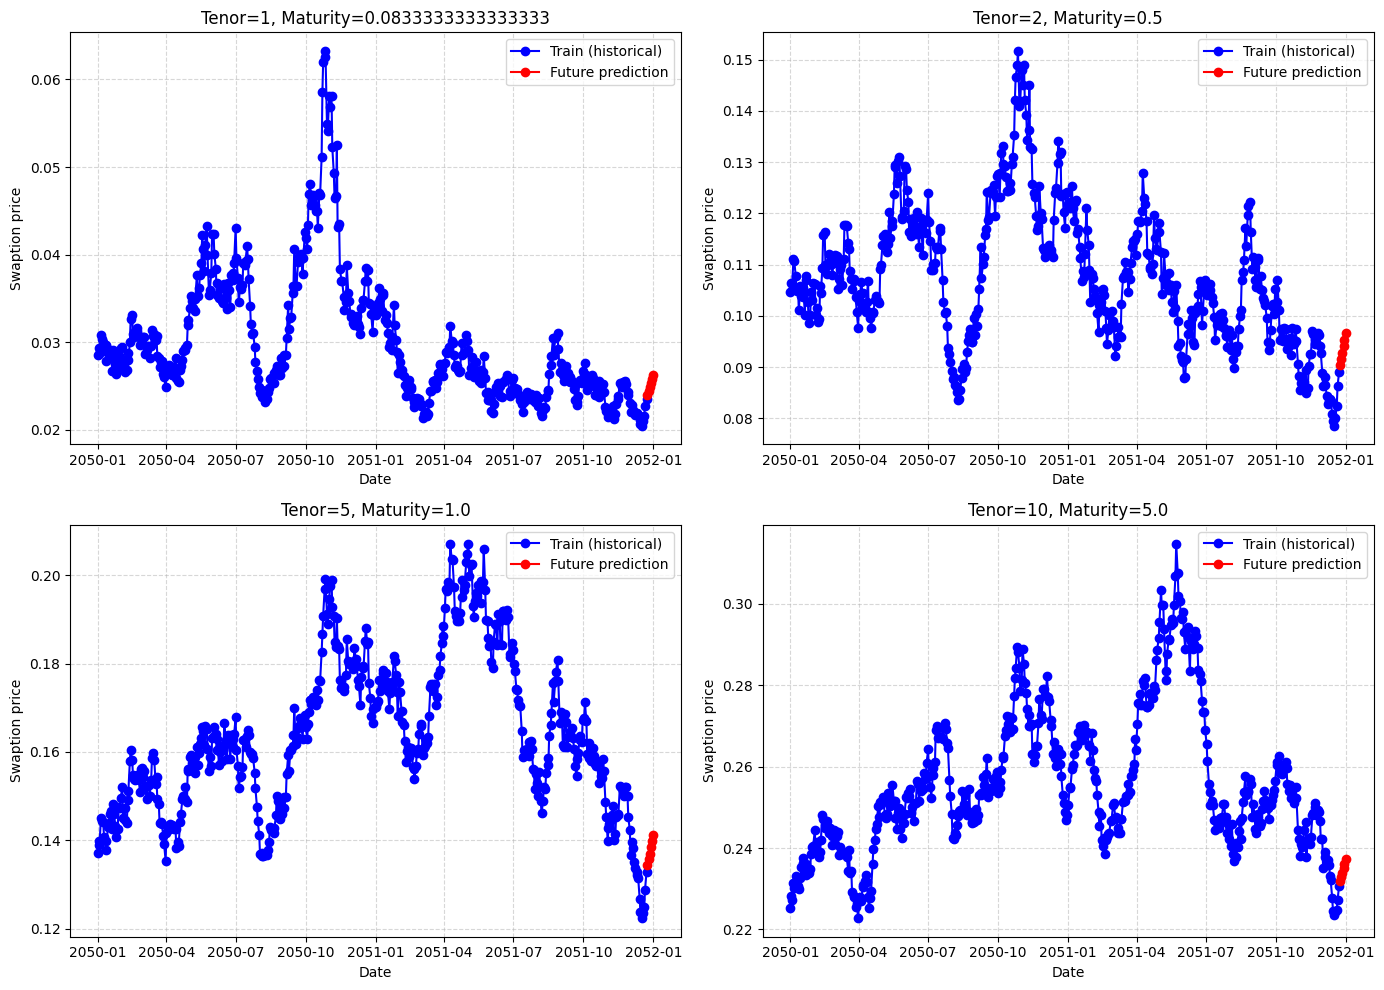

In [6]:
configs = [
    (1, 0.0833333333333333),
    (2, 0.5),
    (5, 1.0),
    (10, 5.0)
]

plot_4_configs_train_future(train_df, test_completed, configs)